
# Lab1_3: PDE
Santiago Andrés Angulo Toro CC 1.001.154.362

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



#### **Exercise 1**: Lab1_3: finite-differences with tolerance **Jacobi method**


SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

#### **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

In [8]:
from IPython.display import Image
Image(filename=path+filename4, width=300)

FileNotFoundError: [Errno 2] No such file or directory: 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/Laplace_df_4.png'

In [9]:
#Punto #1
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
L = 1
N = 50
tol = 1e-3
max_iter = 10000

dx = L / N

u = np.zeros((N+1, N+1))
u_new = np.zeros_like(u)

# Condiciones de frontera
u[:,0] = 100      # u(x,0)=100
u[0,:] = 0        # u(0,y)=0
u[-1,:] = 0       # u(L,y)=0
u[:,-1] = 0       # u(x,L)=0

# Iteración Jacobi
for it in range(max_iter):
    u_nuevo = u.copy()

    for i in range(1,N):
        for j in range(1,N):
            u_nuevo[i,j] = 0.25*(u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1])

    error = np.max(np.abs(u_nuevo - u))

    if error < tol:
        print(f"Convergió en {it} iteraciones")
        break

    u = u_nuevo.copy()

Convergió en 2219 iteraciones


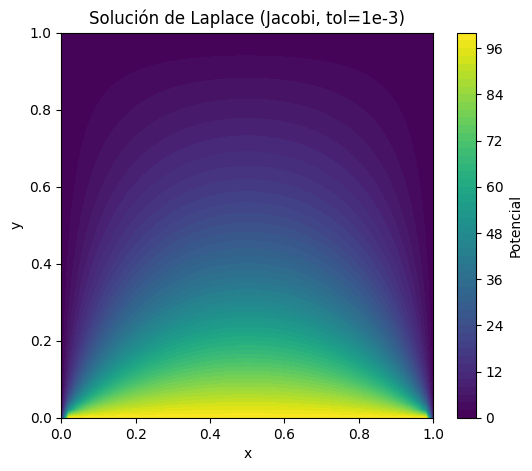

In [10]:
X, Y = np.meshgrid(np.linspace(0,L,N+1), np.linspace(0,L,N+1))

plt.figure(figsize=(6,5))
plt.contourf(X, Y, u.T, 50)
plt.colorbar(label="Potencial")
plt.title("Solución de Laplace (Jacobi, tol=1e-3)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [11]:
def fourier_solucion(x,y,terms=10):
    V0 = 100
    L = 1
    s = 0

    for n in range(1, 2*terms, 2):  # solo impares
        coef = (4*V0)/(n*np.pi)
        s += coef * np.sin(n*np.pi*x/L) * np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

    return s

In [12]:
terminos = 1
error = 1

while error > 1e-3:
    u_fourier = np.zeros_like(u)

    for i in range(N+1):
        for j in range(N+1):
            u_fourier[i,j] = fourier_solucion(X[i,j], Y[i,j], terminos)

    error = np.max(np.abs(u_fourier - u))
    terminos += 1

print("Términos necesarios:", terminos)

/tmp/ipykernel_770/1118266340.py:8: RuntimeWarning: overflow encountered in sinh
  s += coef * np.sin(n*np.pi*x/L) * np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)
/tmp/ipykernel_770/1118266340.py:8: RuntimeWarning: invalid value encountered in scalar multiply
  s += coef * np.sin(n*np.pi*x/L) * np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)
/tmp/ipykernel_770/1118266340.py:8: RuntimeWarning: invalid value encountered in scalar divide
  s += coef * np.sin(n*np.pi*x/L) * np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)


Términos necesarios: 115


In [24]:
#Punto 2
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
L = 100
N = 100
u0 = 100
tol = 1e-3

dx = L/N

# Malla
u = np.zeros((N+1, N+1))
u_nuevo = np.zeros_like(u)

x = np.linspace(0, L, N+1)
y = np.linspace(0, L, N+1)

# Condiciones de frontera

# y = 0  (base)
u[0, :] = u0 * np.sin(2*np.pi*x/L)

# x = 0 y x = L
u[:, 0] = 0
u[:, -1] = 0

# y = L (aprox infinito)
u[-1, :] = 0

# Método de Jacobi

for it in range(10000):
    u_nuevo = u.copy()

    for i in range(1, N):
        for j in range(1, N):
            u_nuevo[i,j] = 0.25*(u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1])

    error = np.max(np.abs(u_nuevo - u))

    if error < tol:
        print("Convergió en", it, "iteraciones")
        break

    u = u_nuevo.copy()

Convergió en 2358 iteraciones


In [26]:
X, Y = np.meshgrid(x, y)

u_exacto = u0 * np.sin(2*np.pi*X/L) * np.exp(-2*np.pi*Y/L)

In [27]:
error = np.max(np.abs(u - u_exacto))
print("Error máximo:", error)

Error máximo: 0.741999063227917


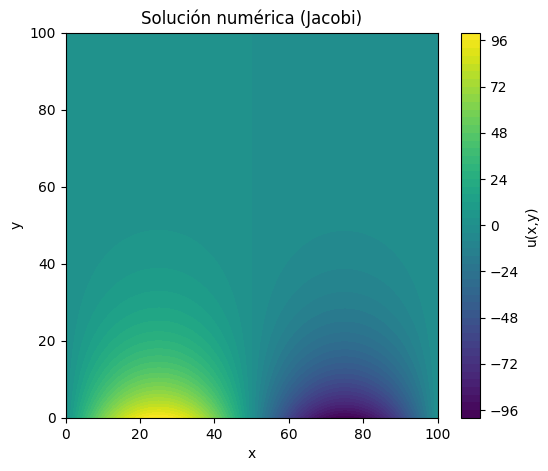

In [28]:
plt.figure(figsize=(6,5))
plt.contourf(X, Y, u, 50)
plt.colorbar(label="u(x,y)")
plt.title("Solución numérica (Jacobi)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

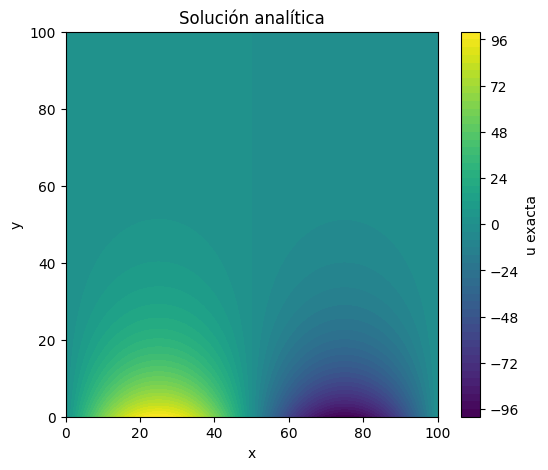

In [29]:
plt.figure(figsize=(6,5))
plt.contourf(X, Y, u_exacto, 50)
plt.colorbar(label="u exacta")
plt.title("Solución analítica")
plt.xlabel("x")
plt.ylabel("y")
plt.show()